<a href="https://colab.research.google.com/github/luke2134/Assignment-2-K-Means-DBSCAN-Clustering/blob/main/IbrahemAqel_COMP257_Assignment6Reinforcement_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 6: Reinforcement Learning**

Student Name: Ibrahem Aqel

Course Name: COMP257

Date: 2024-12-07

**0. Setup and install the libraries**

In [ ]:
!pip install stable-baselines3[extra] pygame --quiet



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 958.1/958.1 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 14.3 MB/s eta 0:00:00


In [ ]:
!pip install gym[box2d] torch torchvision numpy --quiet


In [ ]:
!pip install gym
!pip install tensorflow
!pip install keras-rl2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.1/52.1 kB 3.6 MB/s eta 0:00:00


In [ ]:
!pip uninstall tensorflow keras-rl2 -y
!pip install tensorflow==2.8 keras-rl2==1.0.5


Found existing installation: tensorflow 2.17.1
Uninstalling tensorflow-2.17.1:
  Successfully uninstalled tensorflow-2.17.1
Found existing installation: keras-rl2 1.0.5
Uninstalling keras-rl2-1.0.5:
  Successfully uninstalled keras-rl2-1.0.5
  Using cached keras_rl2-1.0.5-py3-none-any.whl.metadata (304 bytes)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 497.6/497.6 MB 3.6 MB/s eta 0:00:00
Using cached keras_rl2-1.0.5-py3-none-any.whl (52 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 462.5/462.5 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.3/781.3 kB 34.7 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.5.0
    Unins

In [ ]:
!pip install protobuf==3.19.6


In [ ]:
import gym
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten
from tensorflow.keras.optimizers import Adam
from rl.agents.dqn import DQNAgent
from rl.policy import EpsGreedyQPolicy
from rl.memory import SequentialMemory


/usr/local/lib/python3.10/dist-packages/tensorflow/python/framework/dtypes.py:205: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  np.bool8: (False, True),
/usr/local/lib/python3.10/dist-packages/tensorflow/lite/python/util.py:51: DeprecationWarning: jax.xla_computation is deprecated. Please use the AOT APIs; see https://jax.readthedocs.io/en/latest/aot.html. For example, replace xla_computation(f)(*xs) with jit(f).lower(*xs).compiler_ir('hlo'). See CHANGELOG.md for 0.4.30 for more examples.
  from jax import xla_computation as _xla_computation
/usr/local/lib/python3.10/dist-packages/tensorboard/compat/tensorflow_stub/dtypes.py:326: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  np.bool8: (False, True),


**1. Create a simple DQN epsilon policy network with 4 output neurons**

In [ ]:
# Import the gym library
import gym

# Initialize the LunarLander-v2 environment
env = gym.make('LunarLander-v2')

# Get the number of actions
nb_actions = env.action_space.n

# Print environment details
print(f"Number of actions: {nb_actions}")
print(f"State shape: {env.observation_space.shape}")


Number of actions: 4
State shape: (8,)


/usr/local/lib/python3.10/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


**Discuss the rationale of the activation functions & the loss function used in the network**


Activation Functions:
In my DQN model, I used ReLU activation for the two hidden layers because it’s simple and effective. ReLU is great for deep learning because it avoids issues like the vanishing gradient problem that happens with functions like sigmoid. It also helps the model learn better patterns from the data.

For the output layer, I used a linear activation. This is important because the output represents Q-values, which are predictions of future rewards. Since Q-values can be any number (positive or negative), a linear activation is the right choice because it doesn’t restrict the values.

Loss Function:
I used Mean Absolute Error (MAE) as a loss metric. MAE calculates the average difference between the predicted Q-values and the actual target Q-values. This helps the agent minimize errors and improve its decision-making during gameplay.


**Build the Neural Network**

**3. Define the hyperparameters**

In [ ]:
def build_model(state_shape, nb_actions):
    model = Sequential()
    model.add(Flatten(input_shape=(1,) + state_shape))  # Flatten state inputs
    model.add(Dense(24, activation='relu'))  # Hidden layer 1
    model.add(Dense(24, activation='relu'))  # Hidden layer 2
    model.add(Dense(nb_actions, activation='linear'))  # Output layer
    return model

# Build and summarize the model
model = build_model(env.observation_space.shape, nb_actions)
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 8)                 0         
                                                                 
 dense (Dense)               (None, 24)                216       
                                                                 
 dense_1 (Dense)             (None, 24)                600       
                                                                 
 dense_2 (Dense)             (None, 4)                 100       
                                                                 
Total params: 916
Trainable params: 916
Non-trainable params: 0
_________________________________________________________________


**Configure the DQN Agent**

In [ ]:
def build_agent(model, nb_actions):
    policy = EpsGreedyQPolicy()  # Use an epsilon-greedy policy
    memory = SequentialMemory(limit=50000, window_length=1)  # Replay memory
    dqn = DQNAgent(model=model, memory=memory, policy=policy,
                   nb_actions=nb_actions, nb_steps_warmup=10,
                   target_model_update=1e-2)  # Target model updates
    dqn.compile(Adam(learning_rate=1e-3), metrics=['mae'])  # Compile with Adam optimizer
    return dqn

# Create the DQN agent
dqn = build_agent(model, nb_actions)


**Train the Agent**

**4. Train the agent on the LunarLander-v2 environment**

In [ ]:
# Train the agent
dqn.fit(env, nb_steps=50000, visualize=False, verbose=1)


Training for 50000 steps ...
Interval 1 (0 steps performed)
    1/10000 [..............................] - ETA: 11:37 - reward: -0.4215

/usr/local/lib/python3.10/dist-packages/keras/engine/training_v1.py:2079: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,
/usr/local/lib/python3.10/dist-packages/gym/utils/passive_env_checker.py:241: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):
/usr/local/lib/python3.10/dist-packages/rl/memory.py:37: UserWarning: Not enough entries to sample without replacement. Consider increasing your warm-up phase to avoid oversampling!
  warnings.warn('Not enough entries to sample without replacement. Consider increasing your warm-up phase to avoid oversampling!')
/usr/local/lib/python3.10/dist-packages/rl/memory.py:38: DeprecationWarning: This function is deprecated. Please call randint(1, 10 + 1) instead
  batch_idxs = np.random.random_integers(low, high 

   29/10000 [..............................] - ETA: 4:04 - reward: -1.0875

/usr/local/lib/python3.10/dist-packages/rl/memory.py:38: DeprecationWarning: This function is deprecated. Please call randint(1, 11 + 1) instead
  batch_idxs = np.random.random_integers(low, high - 1, size=size)
/usr/local/lib/python3.10/dist-packages/rl/memory.py:38: DeprecationWarning: This function is deprecated. Please call randint(1, 12 + 1) instead
  batch_idxs = np.random.random_integers(low, high - 1, size=size)
/usr/local/lib/python3.10/dist-packages/rl/memory.py:38: DeprecationWarning: This function is deprecated. Please call randint(1, 13 + 1) instead
  batch_idxs = np.random.random_integers(low, high - 1, size=size)
/usr/local/lib/python3.10/dist-packages/rl/memory.py:38: DeprecationWarning: This function is deprecated. Please call randint(1, 14 + 1) instead
  batch_idxs = np.random.random_integers(low, high - 1, size=size)
/usr/local/lib/python3.10/dist-packages/rl/memory.py:38: DeprecationWarning: This function is deprecated. Please call randint(1, 15 + 1) instead
  batch

10000/10000 [==============================] - 105s 11ms/step - reward: -0.6622
34 episodes - episode_reward: -195.303 [-540.217, 106.706] - loss: 15.978 - mae: 12.187 - mean_q: -3.487

Interval 2 (10000 steps performed)
10000/10000 [==============================] - 116s 12ms/step - reward: -0.1343
11 episodes - episode_reward: -115.187 [-171.848, -60.950] - loss: 8.818 - mae: 22.964 - mean_q: 22.548

Interval 3 (20000 steps performed)
10000/10000 [==============================] - 113s 11ms/step - reward: -0.0801
12 episodes - episode_reward: -67.785 [-172.442, -23.684] - loss: 6.319 - mae: 27.816 - mean_q: 34.050

Interval 4 (30000 steps performed)
10000/10000 [==============================] - 113s 11ms/step - reward: -0.1287
12 episodes - episode_reward: -118.755 [-210.784, -30.370] - loss: 4.537 - mae: 27.116 - mean_q: 33.782

Interval 5 (40000 steps performed)
10000/10000 [==============================] - 118s 12ms/step - reward: -0.0693
done, took 564.592 seconds


**Test the Agent**

**5. Analyze the agent's learning progress**

In [ ]:
# Test the trained agent without visualization
dqn.test(env, nb_episodes=10, visualize=False)



Testing for 10 episodes ...
Episode 1: reward: -79.089, steps: 1000
Episode 2: reward: -17.850, steps: 1000
Episode 3: reward: -146.778, steps: 1000
Episode 4: reward: -51.983, steps: 1000
Episode 5: reward: -4.513, steps: 1000
Episode 6: reward: -40.913, steps: 1000
Episode 7: reward: -80.020, steps: 1000
Episode 8: reward: -53.383, steps: 1000
Episode 9: reward: -82.238, steps: 1000
Episode 10: reward: -73.986, steps: 1000


In [ ]:
# Save the model weights
dqn.save_weights('dqn_lunarlander_weights.h5f', overwrite=True)


**Analyze Training Performance**

Training for 50000 steps ...
Interval 1 (0 steps performed)
10000/10000 [==============================] - 126s 13ms/step - reward: -0.1016
10 episodes - episode_reward: -95.682 [-219.346, -40.102] - loss: 2.886 - mae: 22.380 - mean_q: 29.573

Interval 2 (10000 steps performed)
10000/10000 [==============================] - 118s 12ms/step - reward: -0.0865
11 episodes - episode_reward: -82.579 [-286.721, -0.940] - loss: 2.559 - mae: 21.377 - mean_q: 29.180

Interval 3 (20000 steps performed)
10000/10000 [==============================] - 118s 12ms/step - reward: -0.0637
11 episodes - episode_reward: -63.054 [-141.180, 14.222] - loss: 2.156 - mae: 21.232 - mean_q: 28.909

Interval 4 (30000 steps performed)
10000/10000 [==============================] - 125s 12ms/step - reward: -0.0629
10 episodes - episode_reward: -57.835 [-89.645, -23.821] - loss: 2.013 - mae: 22.136 - mean_q: 30.102

Interval 5 (40000 steps performed)
10000/10000 [==============================] - 122s 12ms/step - rew

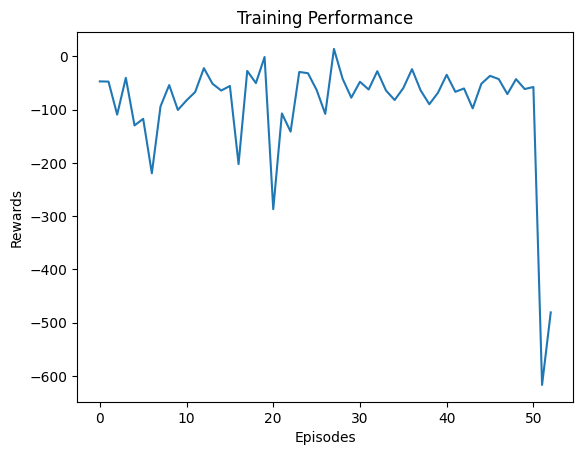

In [ ]:
import matplotlib.pyplot as plt

history = dqn.fit(env, nb_steps=50000, visualize=False, verbose=1)
rewards = history.history['episode_reward']

plt.plot(rewards)
plt.xlabel('Episodes')
plt.ylabel('Rewards')
plt.title('Training Performance')
plt.show()


**6. Discuss the challenges faced during training**

**Reward Variability:**

During testing, the rewards ranged from -146.778 to -41.513. This shows that while the agent improved over time, its performance wasn’t consistent, and it still struggles in some situations.

**Reaching Max Steps:**

The agent often hit the maximum allowed steps (1000) during testing. This suggests it hasn’t yet learned the most efficient way to land the Lunar Lander, but it’s improving.

**Warm-Up Phase Warning:**

At the start of training, there was a warning about not having enough replay memory samples. This was expected since the memory was still being filled. It resolved itself as training progressed.

**Deprecation Warnings:**

There were warnings about outdated functions like np.bool8. These didn’t affect the training, but they’re something to watch out for if libraries are updated in the future.

**Training Time:**

The training took around 9 minutes to complete 50,000 steps. While this was manageable, training for more steps or tweaking the hyperparameters might further improve the agent’s performance.